# Customer Churn Prediction & Risk Segmentation Dashboard 

### TASK 1 — Data Loading & Exploratory Analysis 

##### Step-1:- Load the CSV using Pandas and display shape, column types, and first 10 rows 

In [87]:
# import pandas for analysis
import pandas as pd

In [88]:
# load the data from csv 
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [89]:
#checking the shape of data
data.shape

(7043, 21)

In [90]:
#checking the info of each columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [91]:
#see only top 10 row
data.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


##### Step-2:- Identify the target column (Churn — Yes/No) and check class imbalance

In [92]:
# checking top 10 row whether it is churn -- Yes/No
data["Churn"].head(10)

0     No
1     No
2    Yes
3     No
4    Yes
5    Yes
6     No
7     No
8    Yes
9     No
Name: Churn, dtype: object

In [93]:
# Value counts for No and yes
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [95]:
# Convert into percentage
data["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

##### Step-3:- Find missing/null values and decide how to handle them (drop vs. impute) 

In [96]:
# checking whether is null or not and also there sum 
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [98]:
# check blank values in the TotalCharges column before converting it to numeric format.
(data["TotalCharges"]==" ").sum()

11

In [100]:
# Done to convert TotalCharges into numeric format and handle missing values by replacing them with the median
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())

In [101]:
data["TotalCharges"].isnull().sum()

0

##### Step 4:- Compute summary statistics for numerical columns (mean, median, std)

In [102]:
data[["tenure", "MonthlyCharges", "TotalCharges"]].agg(["mean", "median", "std"])

,tenure,MonthlyCharges,TotalCharges
mean,32.371149,64.761692,2281.916928
median,29.000000,70.350000,1397.475000
std,24.559481,30.090047,2265.270398


##### Step 5:- Plot a correlation heatmap of numerical features using Seaborn

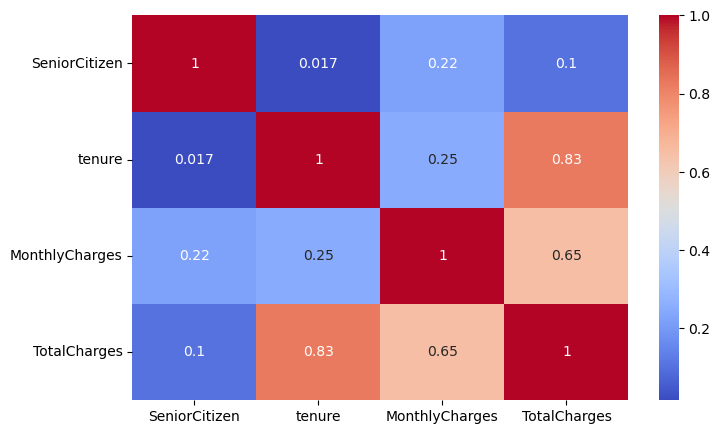

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_data = data.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(8,5))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.show()


## TASK 2 — Data Preprocessing & Feature Engineering

##### Step 1:- Convert TotalCharges to numeric — handle coercion errors carefully 

In [104]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

In [105]:
data["TotalCharges"].isnull().sum()

0

In [106]:
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())

In [107]:
data["TotalCharges"].isnull().sum()

0

##### Step 2:- Encode all categorical columns using Label Encoding or One-Hot Encoding — justify your choice  

In [108]:
data = pd.get_dummies(data, drop_first=True)

In [109]:
data.shape

(7043, 7073)

##### Step 3:- Create at least 2 new features, for example: - ChargesPerMonth = TotalCharges / tenure   - SeniorWithNoSupport = (SeniorCitizen == 1) & (TechSupport == "No")  

In [110]:
data["ChargesPerMonth"] = data["TotalCharges"] / data["tenure"]

In [113]:
import numpy as np

# Doing this to avoid getting infinite as some value are in zero that why and it will fill in median form 
data["ChargesPerMonth"] = data["ChargesPerMonth"].replace([np.inf, -np.inf], np.nan)
data["ChargesPerMonth"] = data["ChargesPerMonth"].fillna(data["ChargesPerMonth"].median())

In [114]:
# assigning value 1 & 0 
data["SeniorWithNoSupport"] = ((data["SeniorCitizen"] == 1) & (data["TechSupport_Yes"] == 0)).astype(int)

In [115]:
data["SeniorWithNoSupport"].value_counts()

SeniorWithNoSupport
0    6161
1     882
Name: count, dtype: int64

##### Step 4:- Scale numerical features using StandardScaler before model training  

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "ChargesPerMonth"]
data[num_cols] = scaler.fit_transform(data[num_cols])

In [117]:
# checking if value is present or not
[col for col in data.columns if "Churn" in col]

['Churn_Yes']

In [118]:
# dropping this to avoid error
X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

##### Step 5 :- Split data into 80% train / 20% test using stratified split

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [121]:
X_train.shape, X_test.shape

((5634, 7074), (1409, 7074))

## TASK 3 — Model Training & Comparison  

In [122]:
# import required tools¶
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#### Step 1:- Train Model 1 — Logistic Regression

In [123]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

#### Step 2:- Model 1 — Evaluate Logistic Regression

In [124]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Accuracy: 0.8041163946061036
Precision: 0.6550632911392406
Recall: 0.553475935828877
F1 Score: 0.6
ROC-AUC: 0.8419334005011755


#### Train Model 2 — Random Forest

In [125]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

#### Model 2 — Evaluate Random Forest

In [126]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.8026969481902059
Precision: 0.6818181818181818
Recall: 0.48128342245989303
F1 Score: 0.5642633228840125
ROC-AUC: 0.8361324239840865


#### Train Model 3 — Gradient Boosting

In [127]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

#### Model 3 —  Evaluate Gradient Boosting

In [128]:
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Accuracy: 0.7927608232789212
Precision: 0.6464285714285715
Recall: 0.4839572192513369
F1 Score: 0.5535168195718655
ROC-AUC: 0.8446666149990959


#### Make Model Comparison Table

In [129]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.655063,0.553476,0.600000,0.841933
1,Random Forest,0.802697,0.681818,0.481283,0.564263,0.836132
2,Gradient Boosting,0.792761,0.646429,0.483957,0.553517,0.844667


#### Step 3:- Plot Confusion Matrix (side-by-side)

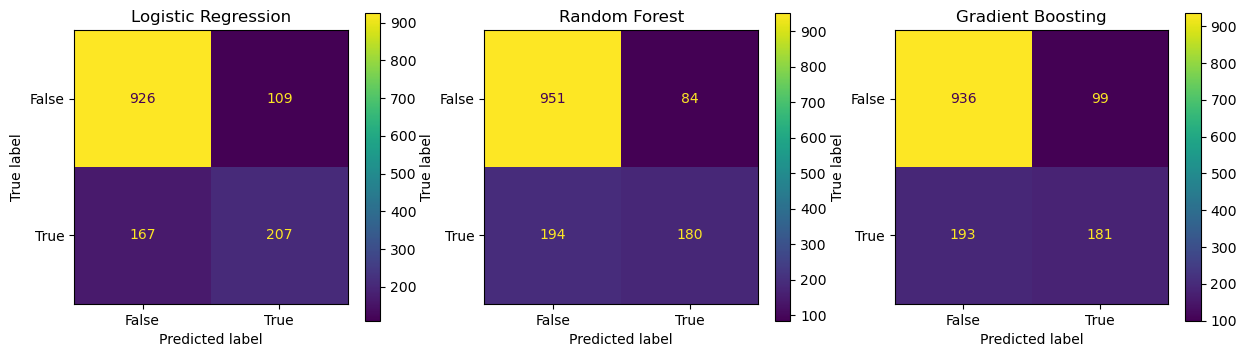

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4))

ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test, ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=axes[1])
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay.from_estimator(gb_model, X_test, y_test, ax=axes[2])
axes[2].set_title("Gradient Boosting")

plt.show()

#### Step 4:- Plot ROC Curve for all 3 models

<Figure size 800x600 with 0 Axes>

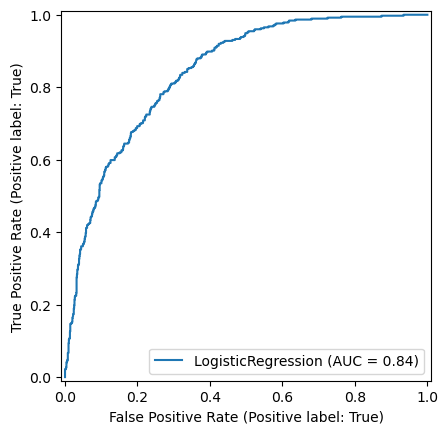

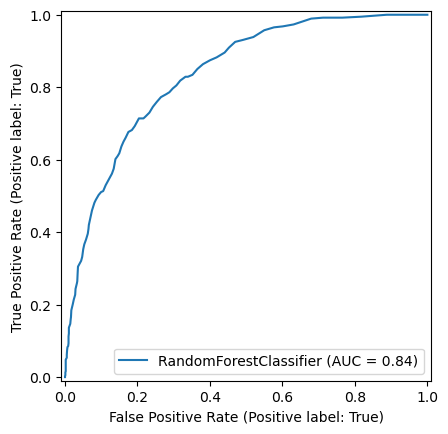

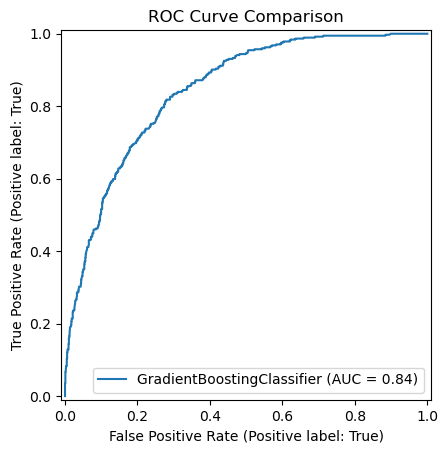

In [67]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(log_model, X_test, y_test)
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
RocCurveDisplay.from_estimator(gb_model, X_test, y_test)

plt.title("ROC Curve Comparison")
plt.show()

#### Step 5:- Perform basic hyperparameter tuning on your best model using GridSearchCV

In [68]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="roc_auc"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

grid.best_params_

{'max_depth': 7, 'n_estimators': 200}

##### I choose GridSearchCV because it evaluates all possible combinations of parameters, making it more accurate in finding the best model configuration.

### TASK 4 — Customer Risk Segmentation

#### Step 1:- Get predicted probabilities

In [132]:
probs = best_model.predict_proba(X_test)[:, 1]

#### Step 2:- Create Risk Tiers

In [74]:
import pandas as pd

risk_df = pd.DataFrame({"Probability": probs})

def risk_category(p):
    if p >= 0.70:
        return "High Risk"
    elif p >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["RiskTier"] = risk_df["Probability"].apply(risk_category)

In [133]:
# Count customers in each risk tier
risk_df["RiskTier"].value_counts()

RiskTier
Low Risk       1392
Medium Risk      17
Name: count, dtype: int64

#### Step 3:- Compute average MonthlyCharges and tenure per risk tier

In [72]:
temp = X_test.copy()

temp["RiskTier"] = risk_df["RiskTier"]
temp["MonthlyCharges"] = data.loc[X_test.index, "MonthlyCharges"]
temp["tenure"] = data.loc[X_test.index, "tenure"]

temp.groupby("RiskTier")[["MonthlyCharges", "tenure"]].mean()

,MonthlyCharges,tenure
RiskTier,,
Low Risk,0.040254,0.035946
Medium Risk,-0.220743,0.204777


#### Contract type distribution

In [73]:
contract_cols = [col for col in data.columns if "Contract" in col]

temp[contract_cols] = data.loc[X_test.index, contract_cols]

temp.groupby("RiskTier")[contract_cols].mean()

,Contract_One year,Contract_Two year
RiskTier,,
Low Risk,0.164062,0.273438
Medium Risk,0.600000,0.000000


#### Step 4:- grouped bar chart comparing the 3 tiers across these key features 

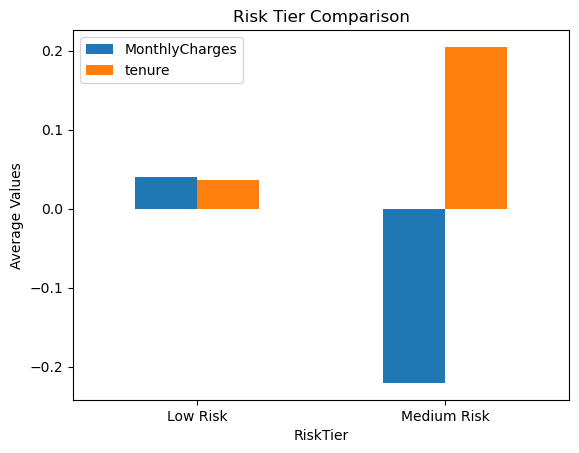

In [75]:
import matplotlib.pyplot as plt

summary = temp.groupby("RiskTier")[["MonthlyCharges", "tenure"]].mean()

summary.plot(kind="bar")
plt.title("Risk Tier Comparison")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.show()

### TASK 5 — Visualizations (Minimum 4 Charts)  

#### Chart 1: Feature Importance

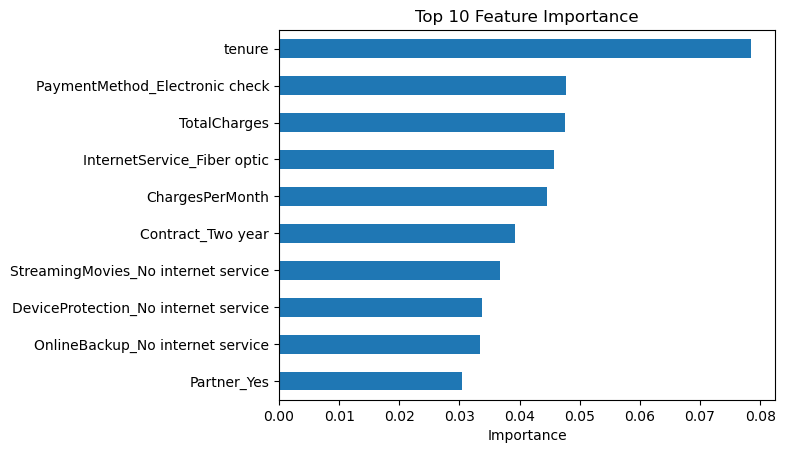

<Figure size 640x480 with 0 Axes>

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

importance = best_model.feature_importances_

feat_imp = pd.Series(importance, index=X_train.columns)
top10 = feat_imp.sort_values(ascending=False).head(10)

top10.plot(kind="barh")
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()
plt.savefig("feature_importance.png")

#### Chart 2: Churn rate by Contract Type (Month-to-Month vs. One Year vs. Two Year)  

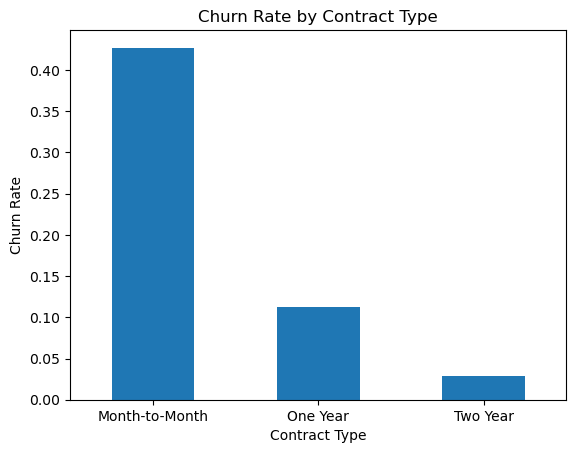

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

contract_type = pd.Series("Month-to-Month", index=data.index)

contract_type[data["Contract_One year"] == 1] = "One Year"
contract_type[data["Contract_Two year"] == 1] = "Two Year"

temp = pd.DataFrame({
    "Contract": contract_type,
    "Churn": data["Churn_Yes"]
})

contract_churn = temp.groupby("Contract")["Churn"].mean()

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)

plt.savefig("churn_by_contract.png")

plt.show()

#### Chart 3: Distribution of tenure — churned vs. not-churned customers

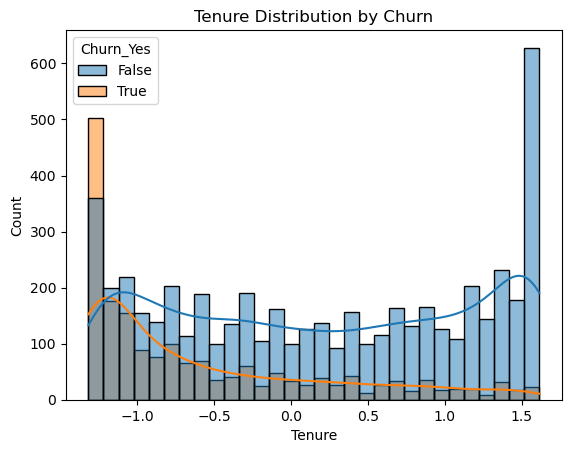

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=data, x="tenure", hue="Churn_Yes", bins=30, kde=True)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure")
plt.ylabel("Count")

plt.savefig("tenure_distribution.png")

plt.show()

#### Chart 4: Risk tier donut/pie chart showing customer count per tier

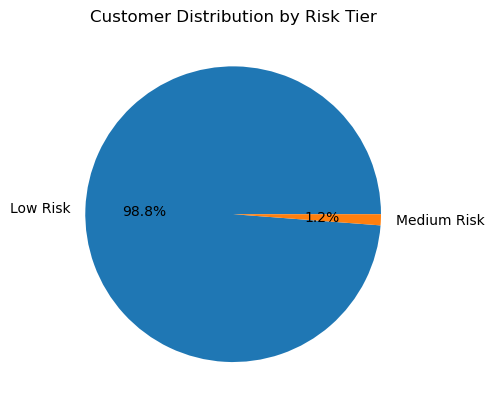

In [86]:
import matplotlib.pyplot as plt

counts = risk_df["RiskTier"].value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%")

plt.title("Customer Distribution by Risk Tier")

plt.savefig("risk_tier_pie.png")

plt.show()

#### Bonus Chart : Interactive scatter plot using Plotly — MonthlyCharges vs. Tenure, colored by churn label 

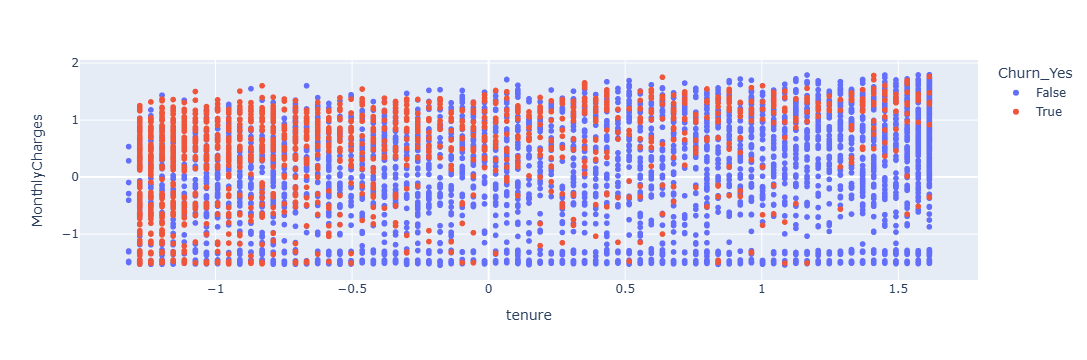

In [83]:
import plotly.express as px

fig = px.scatter(
    data,
    x="tenure",
    y="MonthlyCharges",
    color="Churn_Yes"
)

fig.write_html("scatter_plot.html")

fig.show()

#### TASK 6 — Insights & Business Recommendations

#### Q1 - Which model performed best and why did you select it?

#### Q2 - What are the top 3 factors driving customer churn according to your model?  

#### Q3 - What do High Risk customers have in common? (contract type, charges, tenure patterns)

#### Q4 - Write 2 specific, actionable business recommendations the company should implement

#### Q5 - What are the limitations of your model? What could be improved with more data or time?

#                                                           THANK YOU 

## Name:- Roshan Kumar
## Aspiring Data Analyst